In [1]:
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO

from skimage.feature import (
    local_binary_pattern,
    graycomatrix,
    graycoprops
)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [4]:
CARPETA_PROYECTO = Path(
    r"C:\MachinL\ProyectoFinal"
)

RUTA_SVM = (
    CARPETA_PROYECTO
    / "modelos_ml"
    / "svm_naranjas_final.joblib"
)

POSIBLES_RUTAS_YOLO = [
    CARPETA_PROYECTO
    / "resultados_segmentacion"
    / "orange_yolo11n_seg_30ep"
    / "weights"
    / "yolo_segmentador_naranjas_best.pt",
]

RUTA_YOLO = next(
    (
        ruta
        for ruta in POSIBLES_RUTAS_YOLO
        if ruta.exists()
    ),
    None
)

print("Carpeta del proyecto:")
print(CARPETA_PROYECTO)

print("\nSVM:")
print(RUTA_SVM)
print("Existe:", RUTA_SVM.exists())

print("\nYOLO:")
print(RUTA_YOLO)
print(
    "Existe:",
    RUTA_YOLO is not None
)

Carpeta del proyecto:
C:\MachinL\ProyectoFinal

SVM:
C:\MachinL\ProyectoFinal\modelos_ml\svm_naranjas_final.joblib
Existe: True

YOLO:
C:\MachinL\ProyectoFinal\resultados_segmentacion\orange_yolo11n_seg_30ep\weights\yolo_segmentador_naranjas_best.pt
Existe: True


In [5]:
datos_svm = joblib.load(
    RUTA_SVM
)

modelo_svm = datos_svm["modelo"]

COLUMNAS_CARACTERISTICAS = datos_svm[
    "columnas_caracteristicas"
]

CLASES = datos_svm["clases"]

print("SVM cargado correctamente")
print("Modelo:", type(modelo_svm))
print("Clases:", CLASES)

print(
    "Cantidad de características:",
    len(COLUMNAS_CARACTERISTICAS)
)

print(
    "Macro F1 guardado:",
    datos_svm.get(
        "macro_f1_test",
        "No almacenado"
    )
)

SVM cargado correctamente
Modelo: <class 'sklearn.pipeline.Pipeline'>
Clases: ['Blackspot', 'Canker', 'HLB', 'Healthy', 'Melanosis']
Cantidad de características: 107
Macro F1 guardado: 0.9666110660332137


In [6]:
if RUTA_YOLO is None:
    raise FileNotFoundError(
        "No se encontró el modelo YOLO best.pt"
    )

modelo_yolo = YOLO(
    str(RUTA_YOLO)
)

UMBRAL_YOLO = 0.02

print("YOLO cargado correctamente")
print("Ruta:", RUTA_YOLO)
print("Clases YOLO:", modelo_yolo.names)
print("Umbral:", UMBRAL_YOLO)

YOLO cargado correctamente
Ruta: C:\MachinL\ProyectoFinal\resultados_segmentacion\orange_yolo11n_seg_30ep\weights\yolo_segmentador_naranjas_best.pt
Clases YOLO: {0: 'orange'}
Umbral: 0.02


In [7]:
RUTA_IMAGEN_PRUEBA = Path(
    r"C:\MachinL\ProyectoFinal\Prueva_Fotos_Nuevas\prueva1.jpg"
)

print(
    "Imagen existe:",
    RUTA_IMAGEN_PRUEBA.exists()
)

Imagen existe: True


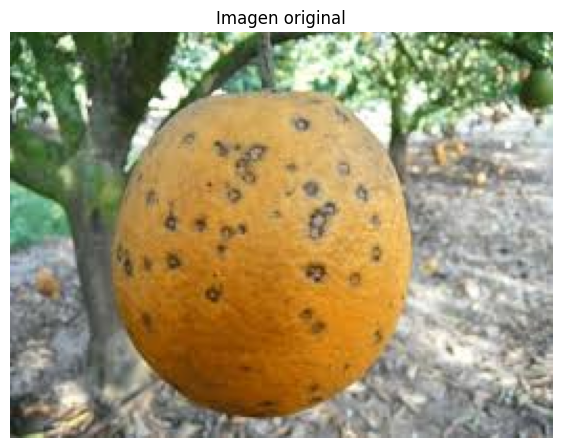

Dimensiones: (194, 259, 3)


In [8]:
imagen_bgr = cv2.imread(
    str(RUTA_IMAGEN_PRUEBA)
)

if imagen_bgr is None:
    raise ValueError(
        "No se pudo leer la imagen seleccionada"
    )

imagen_rgb = cv2.cvtColor(
    imagen_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(7, 7))
plt.imshow(imagen_rgb)
plt.title("Imagen original")
plt.axis("off")
plt.show()

print("Dimensiones:", imagen_rgb.shape)

In [9]:
configuracion = datos_svm.get(
    "configuracion_extractor",
    {}
)

FONDO_GRIS = int(
    configuracion.get("fondo_gris", 127)
)

UMBRAL_FONDO = int(
    configuracion.get("umbral_fondo", 15)
)

LBP_RADIO = int(
    configuracion.get("lbp_radio", 2)
)

LBP_PUNTOS = int(
    configuracion.get(
        "lbp_puntos",
        8 * LBP_RADIO
    )
)

LBP_METODO = configuracion.get(
    "lbp_metodo",
    "uniform"
)

print("Fondo gris:", FONDO_GRIS)
print("Umbral fondo:", UMBRAL_FONDO)
print("LBP radio:", LBP_RADIO)
print("LBP puntos:", LBP_PUNTOS)
print("LBP método:", LBP_METODO)

Fondo gris: 127
Umbral fondo: 15
LBP radio: 2
LBP puntos: 16
LBP método: uniform


In [10]:
def preparar_fruto_cuadrado(
    imagen_rgb,
    mascara,
    margen_porcentual=0.04
):
    alto, ancho = imagen_rgb.shape[:2]

    if mascara.shape != (alto, ancho):
        mascara = cv2.resize(
            mascara,
            (ancho, alto),
            interpolation=cv2.INTER_NEAREST
        )

    mascara = (
        mascara > 0
    ).astype(np.uint8) * 255

    puntos = cv2.findNonZero(
        mascara
    )

    if puntos is None:
        raise ValueError(
            "La máscara del fruto está vacía."
        )

    # Suavizar ligeramente los bordes
    mascara_suave = cv2.GaussianBlur(
        mascara,
        (5, 5),
        0
    )

    alpha = (
        mascara_suave.astype(np.float32)
        / 255.0
    )[:, :, None]

    fondo = np.full_like(
        imagen_rgb,
        FONDO_GRIS
    )

    imagen_fondo_gris = (
        imagen_rgb.astype(np.float32) * alpha
        +
        fondo.astype(np.float32) * (1.0 - alpha)
    ).astype(np.uint8)

    # Caja alrededor del fruto
    x, y, ancho_caja, alto_caja = (
        cv2.boundingRect(puntos)
    )

    margen = int(
        max(ancho_caja, alto_caja)
        * margen_porcentual
    )

    x1 = max(0, x - margen)
    y1 = max(0, y - margen)

    x2 = min(
        ancho,
        x + ancho_caja + margen
    )

    y2 = min(
        alto,
        y + alto_caja + margen
    )

    recorte = imagen_fondo_gris[
        y1:y2,
        x1:x2
    ]

    alto_recorte, ancho_recorte = (
        recorte.shape[:2]
    )

    if alto_recorte == 0 or ancho_recorte == 0:
        raise ValueError(
            "El recorte generado está vacío."
        )

    lado = max(
        alto_recorte,
        ancho_recorte
    )

    imagen_cuadrada = np.full(
        (lado, lado, 3),
        FONDO_GRIS,
        dtype=np.uint8
    )

    desplazamiento_x = (
        lado - ancho_recorte
    ) // 2

    desplazamiento_y = (
        lado - alto_recorte
    ) // 2

    imagen_cuadrada[
        desplazamiento_y:
        desplazamiento_y + alto_recorte,

        desplazamiento_x:
        desplazamiento_x + ancho_recorte
    ] = recorte

    return (
        imagen_cuadrada,
        mascara,
        imagen_fondo_gris
    )

In [11]:
def segmentar_naranja_yolo(
    imagen_rgb
):
    if imagen_rgb is None:
        raise ValueError(
            "No se recibió una imagen."
        )

    resultados = modelo_yolo.predict(
        source=imagen_rgb,
        conf=UMBRAL_YOLO,
        iou=0.7,
        classes=[0],
        max_det=5,
        retina_masks=True,
        verbose=False
    )

    if len(resultados) == 0:
        raise ValueError(
            "YOLO no devolvió resultados."
        )

    resultado = resultados[0]

    if (
        resultado.masks is None
        or resultado.boxes is None
        or len(resultado.boxes) == 0
    ):
        raise ValueError(
            "YOLO no detectó una naranja."
        )

    mascaras = (
        resultado.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    confianzas = (
        resultado.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    # Elegir la máscara de mayor área
    areas = mascaras.reshape(
        mascaras.shape[0],
        -1
    ).sum(axis=1)

    indice_principal = int(
        np.argmax(areas)
    )

    mascara_principal = (
        mascaras[indice_principal] > 0.5
    ).astype(np.uint8) * 255

    confianza_yolo = float(
        confianzas[indice_principal]
    )

    (
        imagen_cuadrada,
        mascara_original,
        imagen_fondo_gris
    ) = preparar_fruto_cuadrado(
        imagen_rgb,
        mascara_principal
    )

    return {
        "imagen_cuadrada": imagen_cuadrada,
        "mascara": mascara_original,
        "imagen_fondo_gris": imagen_fondo_gris,
        "confianza_yolo": confianza_yolo,
        "numero_detecciones": len(mascaras)
    }

In [12]:
resultado_segmentacion = (
    segmentar_naranja_yolo(
        imagen_rgb
    )
)

imagen_cuadrada = resultado_segmentacion[
    "imagen_cuadrada"
]

mascara_yolo = resultado_segmentacion[
    "mascara"
]

imagen_fondo_gris = resultado_segmentacion[
    "imagen_fondo_gris"
]

confianza_yolo = resultado_segmentacion[
    "confianza_yolo"
]

print(
    "Detecciones:",
    resultado_segmentacion[
        "numero_detecciones"
    ]
)

print(
    "Confianza YOLO:",
    f"{confianza_yolo:.2%}"
)

print(
    "Dimensiones finales:",
    imagen_cuadrada.shape
)

Detecciones: 1
Confianza YOLO: 4.30%
Dimensiones finales: (170, 170, 3)


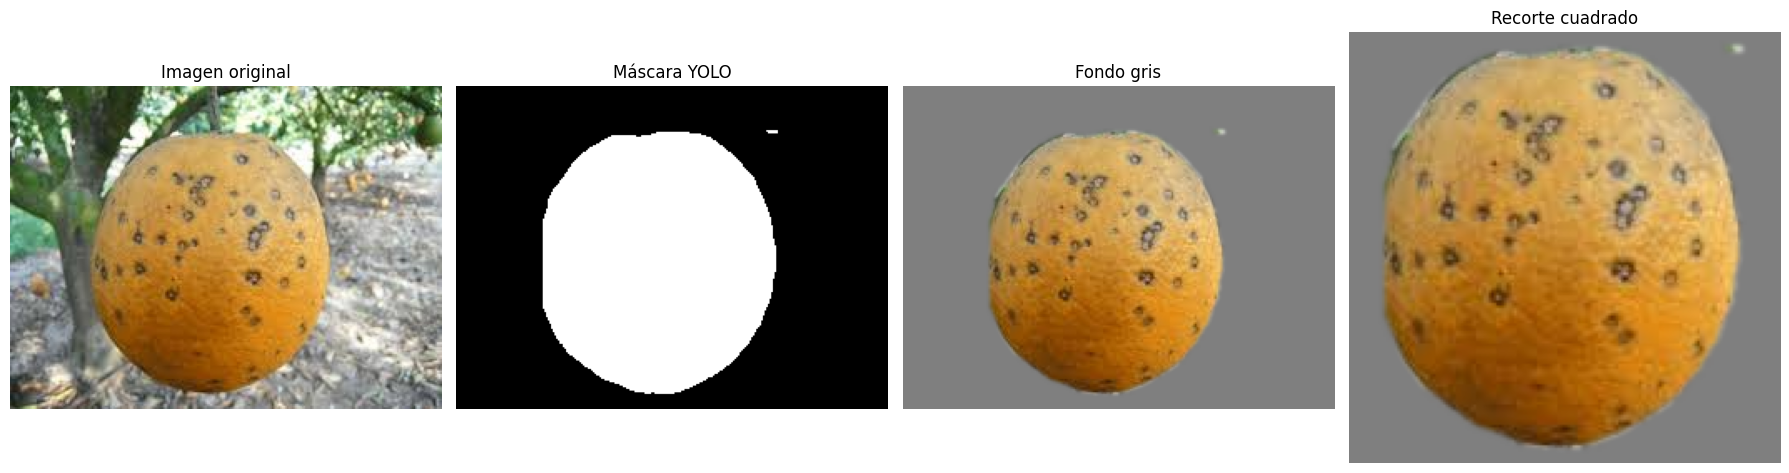

In [13]:
figura, ejes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

ejes[0].imshow(
    imagen_rgb
)
ejes[0].set_title(
    "Imagen original"
)
ejes[0].axis("off")

ejes[1].imshow(
    mascara_yolo,
    cmap="gray"
)
ejes[1].set_title(
    "Máscara YOLO"
)
ejes[1].axis("off")

ejes[2].imshow(
    imagen_fondo_gris
)
ejes[2].set_title(
    "Fondo gris"
)
ejes[2].axis("off")

ejes[3].imshow(
    imagen_cuadrada
)
ejes[3].set_title(
    "Recorte cuadrado"
)
ejes[3].axis("off")

plt.tight_layout()
plt.show()

In [14]:
RUTA_IMAGEN_PROCESADA = (
    CARPETA_PROYECTO
    / "resultado_segmentacion_prueba.png"
)

imagen_bgr_guardar = cv2.cvtColor(
    imagen_cuadrada,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(
    str(RUTA_IMAGEN_PROCESADA),
    imagen_bgr_guardar
)

print(
    "Imagen guardada en:",
    RUTA_IMAGEN_PROCESADA
)

print(
    "Existe:",
    RUTA_IMAGEN_PROCESADA.exists()
)

Imagen guardada en: C:\MachinL\ProyectoFinal\resultado_segmentacion_prueba.png
Existe: True


In [24]:
def crear_mascara_fruto(imagen_rgb):
    """
    Separa el fruto del fondo gris.
    """

    imagen_float = imagen_rgb.astype(
        np.float32
    )

    fondo = np.array(
        [
            FONDO_GRIS,
            FONDO_GRIS,
            FONDO_GRIS
        ],
        dtype=np.float32
    )

    diferencia = np.linalg.norm(
        imagen_float - fondo,
        axis=2
    )

    mascara = (
        diferencia > UMBRAL_FONDO
    ).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_OPEN,
        kernel
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_CLOSE,
        kernel
    )

    numero_componentes, etiquetas, estadisticas, _ = (
        cv2.connectedComponentsWithStats(
            mascara,
            connectivity=8
        )
    )

    if numero_componentes <= 1:
        return mascara

    areas = estadisticas[
        1:,
        cv2.CC_STAT_AREA
    ]

    componente_mayor = (
        1 + int(np.argmax(areas))
    )

    mascara_principal = (
        etiquetas == componente_mayor
    ).astype(np.uint8) * 255

    return mascara_principal

In [25]:
def estadisticas_canal(
    imagen,
    mascara_bool,
    prefijos
):
    caracteristicas = {}

    for indice, nombre in enumerate(
        prefijos
    ):
        valores = imagen[
            :, :,
            indice
        ][mascara_bool]

        if valores.size == 0:
            media = 0.0
            desviacion = 0.0
            mediana = 0.0

        else:
            media = float(
                np.mean(valores)
            )

            desviacion = float(
                np.std(valores)
            )

            mediana = float(
                np.median(valores)
            )

        caracteristicas[
            f"{nombre}_media"
        ] = media

        caracteristicas[
            f"{nombre}_std"
        ] = desviacion

        caracteristicas[
            f"{nombre}_mediana"
        ] = mediana

    return caracteristicas

In [26]:
def extraer_estadisticas_color(
    imagen_rgb,
    mascara
):
    mascara_bool = mascara > 0

    imagen_hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    imagen_lab = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2LAB
    )

    caracteristicas = {}

    caracteristicas.update(
        estadisticas_canal(
            imagen_rgb,
            mascara_bool,
            ["R", "G", "B"]
        )
    )

    caracteristicas.update(
        estadisticas_canal(
            imagen_hsv,
            mascara_bool,
            ["H", "S", "V"]
        )
    )

    caracteristicas.update(
        estadisticas_canal(
            imagen_lab,
            mascara_bool,
            ["L", "A", "LAB_B"]
        )
    )

    return caracteristicas

In [27]:
def histograma_normalizado(
    canal,
    mascara,
    numero_bins,
    rango
):
    histograma = cv2.calcHist(
        [canal],
        [0],
        mascara,
        [numero_bins],
        rango
    )

    histograma = histograma.flatten()

    suma = histograma.sum()

    if suma > 0:
        histograma = histograma / suma

    return histograma

In [28]:
def extraer_histogramas_hsv(
    imagen_rgb,
    mascara,
    bins_h=18,
    bins_s=16,
    bins_v=16
):
    imagen_hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    h, s, v = cv2.split(
        imagen_hsv
    )

    hist_h = histograma_normalizado(
        h,
        mascara,
        bins_h,
        [0, 180]
    )

    hist_s = histograma_normalizado(
        s,
        mascara,
        bins_s,
        [0, 256]
    )

    hist_v = histograma_normalizado(
        v,
        mascara,
        bins_v,
        [0, 256]
    )

    caracteristicas = {}

    for indice, valor in enumerate(
        hist_h
    ):
        caracteristicas[
            f"hist_h_{indice:02d}"
        ] = float(valor)

    for indice, valor in enumerate(
        hist_s
    ):
        caracteristicas[
            f"hist_s_{indice:02d}"
        ] = float(valor)

    for indice, valor in enumerate(
        hist_v
    ):
        caracteristicas[
            f"hist_v_{indice:02d}"
        ] = float(valor)

    return caracteristicas

In [19]:
def extraer_lbp(
    imagen_rgb,
    mascara
):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )

    lbp = local_binary_pattern(
        gris,
        P=LBP_PUNTOS,
        R=LBP_RADIO,
        method=LBP_METODO
    )

    valores_lbp = lbp[
        mascara > 0
    ]

    numero_bins = (
        LBP_PUNTOS + 2
    )

    histograma, _ = np.histogram(
        valores_lbp,
        bins=np.arange(
            0,
            numero_bins + 1
        ),
        range=(0, numero_bins)
    )

    histograma = histograma.astype(
        np.float32
    )

    if histograma.sum() > 0:
        histograma /= histograma.sum()

    return {
        f"lbp_{indice:02d}": float(valor)
        for indice, valor
        in enumerate(histograma)
    }

In [20]:
def extraer_glcm(
    imagen_rgb,
    mascara
):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )

    puntos = cv2.findNonZero(
        mascara
    )

    if puntos is None:
        return {
            "glcm_contraste": 0.0,
            "glcm_disimilitud": 0.0,
            "glcm_homogeneidad": 0.0,
            "glcm_energia": 0.0,
            "glcm_correlacion": 0.0,
            "glcm_ASM": 0.0
        }

    x, y, ancho, alto = cv2.boundingRect(
        puntos
    )

    recorte_gris = gris[
        y:y + alto,
        x:x + ancho
    ].copy()

    recorte_mascara = mascara[
        y:y + alto,
        x:x + ancho
    ] > 0

    valores_fruto = recorte_gris[
        recorte_mascara
    ]

    if valores_fruto.size == 0:
        valor_relleno = FONDO_GRIS

    else:
        valor_relleno = int(
            np.median(valores_fruto)
        )

    recorte_gris[
        ~recorte_mascara
    ] = valor_relleno

    recorte_gris = cv2.resize(
        recorte_gris,
        (128, 128),
        interpolation=cv2.INTER_AREA
    )

    imagen_cuantizada = (
        recorte_gris // 16
    ).astype(np.uint8)

    matriz_glcm = graycomatrix(
        imagen_cuantizada,
        distances=[1, 2],
        angles=[
            0,
            np.pi / 4,
            np.pi / 2,
            3 * np.pi / 4
        ],
        levels=16,
        symmetric=True,
        normed=True
    )

    propiedades = {
        "contraste": "contrast",
        "disimilitud": "dissimilarity",
        "homogeneidad": "homogeneity",
        "energia": "energy",
        "correlacion": "correlation",
        "ASM": "ASM"
    }

    caracteristicas = {}

    for nombre, propiedad in (
        propiedades.items()
    ):
        valores = graycoprops(
            matriz_glcm,
            propiedad
        )

        caracteristicas[
            f"glcm_{nombre}"
        ] = float(
            np.mean(valores)
        )

    return caracteristicas

In [21]:
def extraer_proporciones_color(
    imagen_rgb,
    mascara
):
    hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    h, s, v = cv2.split(
        hsv
    )

    fruto = mascara > 0

    total = int(
        np.sum(fruto)
    )

    if total == 0:
        return {
            "proporcion_oscura": 0.0,
            "proporcion_amarilla": 0.0,
            "proporcion_verde": 0.0,
            "proporcion_marron": 0.0,
            "proporcion_baja_saturacion": 0.0
        }

    oscura = (
        fruto
        & (v < 80)
    )

    amarilla = (
        fruto
        & (h >= 18)
        & (h <= 38)
        & (s > 60)
        & (v > 80)
    )

    verde = (
        fruto
        & (h >= 35)
        & (h <= 90)
        & (s > 40)
    )

    marron = (
        fruto
        & (
            (h <= 18)
            | (h >= 170)
        )
        & (s > 40)
        & (v >= 40)
        & (v <= 180)
    )

    baja_saturacion = (
        fruto
        & (s < 45)
    )

    return {
        "proporcion_oscura": float(
            np.sum(oscura) / total
        ),
        "proporcion_amarilla": float(
            np.sum(amarilla) / total
        ),
        "proporcion_verde": float(
            np.sum(verde) / total
        ),
        "proporcion_marron": float(
            np.sum(marron) / total
        ),
        "proporcion_baja_saturacion": float(
            np.sum(baja_saturacion) / total
        )
    }

In [22]:
def extraer_caracteristicas_imagen(
    imagen_rgb
):
    mascara = crear_mascara_fruto(
        imagen_rgb
    )

    cantidad_pixeles = int(
        np.sum(mascara > 0)
    )

    if cantidad_pixeles < 100:
        raise ValueError(
            "La máscara contiene muy pocos "
            f"píxeles: {cantidad_pixeles}"
        )

    caracteristicas = {}

    caracteristicas.update(
        extraer_estadisticas_color(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_histogramas_hsv(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_lbp(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_glcm(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_proporciones_color(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas[
        "area_relativa_fruto"
    ] = float(
        np.mean(mascara > 0)
    )

    return caracteristicas, mascara

In [29]:
caracteristicas_nueva, mascara_final = (
    extraer_caracteristicas_imagen(
        imagen_cuadrada
    )
)

print(
    "Características extraídas:",
    len(caracteristicas_nueva)
)

columnas_faltantes = [
    columna
    for columna in COLUMNAS_CARACTERISTICAS
    if columna not in caracteristicas_nueva
]

columnas_extra = [
    columna
    for columna in caracteristicas_nueva
    if columna not in COLUMNAS_CARACTERISTICAS
]

print(
    "Columnas faltantes:",
    columnas_faltantes
)

print(
    "Columnas adicionales:",
    columnas_extra
)

Características extraídas: 107
Columnas faltantes: []
Columnas adicionales: []


In [30]:
valores_caracteristicas = np.array(
    list(
        caracteristicas_nueva.values()
    ),
    dtype=np.float64
)

print(
    "NaN:",
    np.isnan(
        valores_caracteristicas
    ).sum()
)

print(
    "Inf:",
    np.isinf(
        valores_caracteristicas
    ).sum()
)

NaN: 0
Inf: 0


In [31]:
fila_caracteristicas = {
    columna: caracteristicas_nueva[columna]
    for columna in COLUMNAS_CARACTERISTICAS
}

df_entrada = pd.DataFrame(
    [fila_caracteristicas],
    columns=COLUMNAS_CARACTERISTICAS
)

print(
    "Dimensiones de entrada:",
    df_entrada.shape
)

display(
    df_entrada.iloc[
        :,
        :10
    ]
)

Dimensiones de entrada: (1, 107)


,R_media,R_std,R_mediana,G_media,G_std,G_mediana,B_media,B_std,B_mediana,H_media
0,182.925873,34.914295,189.0,133.138246,37.245201,138.0,61.217487,43.426339,60.0,18.167171


In [32]:
clase_predicha = modelo_svm.predict(
    df_entrada
)[0]

probabilidades = modelo_svm.predict_proba(
    df_entrada
)[0]

clases_internas = (
    modelo_svm
    .named_steps["clasificador"]
    .classes_
)

resultado_probabilidades = {
    clase: float(probabilidad)
    for clase, probabilidad
    in zip(
        clases_internas,
        probabilidades
    )
}

resultado_probabilidades = dict(
    sorted(
        resultado_probabilidades.items(),
        key=lambda elemento: elemento[1],
        reverse=True
    )
)

confianza_svm = float(
    np.max(probabilidades)
)

print(
    "Enfermedad predicha:",
    clase_predicha
)

print(
    "Confianza SVM:",
    f"{confianza_svm:.2%}"
)

print(
    "Confianza YOLO:",
    f"{confianza_yolo:.2%}"
)

print("\nProbabilidades:")

for clase, probabilidad in (
    resultado_probabilidades.items()
):
    print(
        f"{clase:12s}: "
        f"{probabilidad:.2%}"
    )

Enfermedad predicha: Canker
Confianza SVM: 58.77%
Confianza YOLO: 4.30%

Probabilidades:
Canker      : 58.77%
Blackspot   : 15.82%
Healthy     : 13.25%
Melanosis   : 9.85%
HLB         : 2.31%


c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


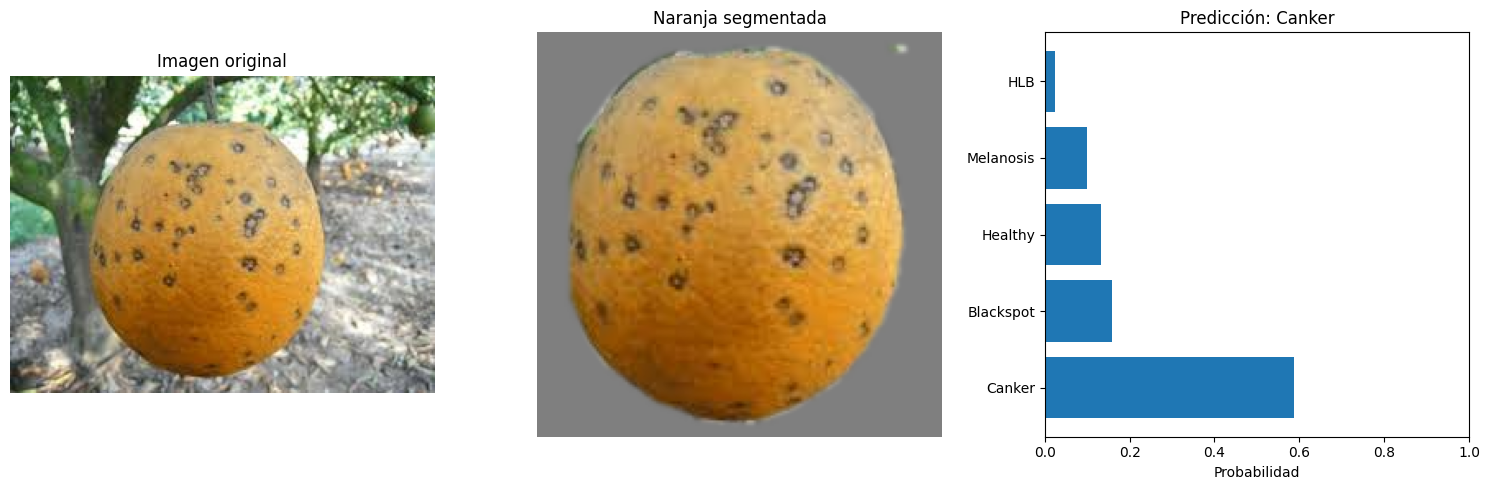

In [33]:
figura, ejes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

ejes[0].imshow(
    imagen_rgb
)

ejes[0].set_title(
    "Imagen original"
)

ejes[0].axis("off")

ejes[1].imshow(
    imagen_cuadrada
)

ejes[1].set_title(
    "Naranja segmentada"
)

ejes[1].axis("off")

ejes[2].barh(
    list(
        resultado_probabilidades.keys()
    ),
    list(
        resultado_probabilidades.values()
    )
)

ejes[2].set_xlim(
    0,
    1
)

ejes[2].set_xlabel(
    "Probabilidad"
)

ejes[2].set_title(
    f"Predicción: {clase_predicha}"
)

plt.tight_layout()
plt.show()

In [35]:
import gradio as gr
import traceback

print("Versión de Gradio:", gr.__version__)

Versión de Gradio: 6.19.0


In [36]:
def preparar_imagen_entrada(imagen):
    """
    Convierte la entrada de Gradio en una imagen
    RGB uint8 compatible con OpenCV y YOLO.
    """

    if imagen is None:
        raise ValueError(
            "Debes seleccionar una imagen."
        )

    imagen = np.asarray(imagen)

    if imagen.ndim == 2:
        imagen_rgb = cv2.cvtColor(
            imagen,
            cv2.COLOR_GRAY2RGB
        )

    elif (
        imagen.ndim == 3
        and imagen.shape[2] == 4
    ):
        imagen_rgb = cv2.cvtColor(
            imagen,
            cv2.COLOR_RGBA2RGB
        )

    elif (
        imagen.ndim == 3
        and imagen.shape[2] == 3
    ):
        imagen_rgb = imagen.copy()

    else:
        raise ValueError(
            "El formato de la imagen no es compatible."
        )

    if imagen_rgb.dtype != np.uint8:

        if imagen_rgb.max() <= 1.0:
            imagen_rgb = imagen_rgb * 255.0

        imagen_rgb = np.clip(
            imagen_rgb,
            0,
            255
        ).astype(np.uint8)

    return imagen_rgb

In [37]:
def preparar_vector_svm(
    caracteristicas
):
    """
    Ordena las características exactamente como
    fueron utilizadas para entrenar el SVM.
    """

    columnas_faltantes = [
        columna
        for columna in COLUMNAS_CARACTERISTICAS
        if columna not in caracteristicas
    ]

    if columnas_faltantes:
        raise ValueError(
            "Faltan características: "
            + ", ".join(columnas_faltantes)
        )

    vector = np.array(
        [[
            caracteristicas[columna]
            for columna
            in COLUMNAS_CARACTERISTICAS
        ]],
        dtype=np.float64
    )

    if vector.shape[1] != len(
        COLUMNAS_CARACTERISTICAS
    ):
        raise ValueError(
            "La cantidad de características "
            "no coincide con el modelo."
        )

    if not np.all(
        np.isfinite(vector)
    ):
        raise ValueError(
            "El vector contiene valores NaN "
            "o infinitos."
        )

    return vector

In [38]:
def analizar_naranja(imagen):
    """
    Flujo completo:

    Imagen original
    → YOLO
    → fondo gris y recorte cuadrado
    → extracción de 107 características
    → SVM
    → enfermedad y probabilidades
    """

    if imagen is None:
        return (
            None,
            {},
            "Debes subir una imagen."
        )

    try:
        # 1. Preparar imagen
        imagen_rgb = preparar_imagen_entrada(
            imagen
        )

        # 2. Segmentar con YOLO
        resultado_yolo = (
            segmentar_naranja_yolo(
                imagen_rgb
            )
        )

        imagen_segmentada = resultado_yolo[
            "imagen_cuadrada"
        ]

        confianza_yolo = float(
            resultado_yolo[
                "confianza_yolo"
            ]
        )

        numero_detecciones = int(
            resultado_yolo[
                "numero_detecciones"
            ]
        )

        # 3. Extraer características
        caracteristicas, mascara_final = (
            extraer_caracteristicas_imagen(
                imagen_segmentada
            )
        )

        # 4. Ordenar vector para el SVM
        vector_svm = preparar_vector_svm(
            caracteristicas
        )

        # 5. Predicción
        clase_predicha = modelo_svm.predict(
            vector_svm
        )[0]

        probabilidades = (
            modelo_svm.predict_proba(
                vector_svm
            )[0]
        )

        clases_internas = (
            modelo_svm
            .named_steps["clasificador"]
            .classes_
        )

        probabilidades_dict = {
            str(clase): float(probabilidad)
            for clase, probabilidad
            in zip(
                clases_internas,
                probabilidades
            )
        }

        probabilidades_dict = dict(
            sorted(
                probabilidades_dict.items(),
                key=lambda elemento: elemento[1],
                reverse=True
            )
        )

        confianza_svm = float(
            np.max(probabilidades)
        )

        # 6. Mensajes de control
        observacion_yolo = ""

        if confianza_yolo < 0.10:
            observacion_yolo = (
                "\nAdvertencia: la confianza de "
                "segmentación es baja. Revisa el "
                "recorte mostrado."
            )

        resultado_texto = (
            f"Enfermedad predicha: "
            f"{clase_predicha}\n\n"

            f"Confianza del SVM: "
            f"{confianza_svm:.2%}\n"

            f"Confianza de YOLO: "
            f"{confianza_yolo:.2%}\n"

            f"Detecciones encontradas: "
            f"{numero_detecciones}\n"

            f"Características utilizadas: "
            f"{vector_svm.shape[1]}"
            f"{observacion_yolo}"
        )

        return (
            imagen_segmentada,
            probabilidades_dict,
            resultado_texto
        )

    except Exception as error:
        print("\nERROR COMPLETO:")
        traceback.print_exc()

        return (
            None,
            {},
            (
                f"No se pudo analizar la imagen.\n\n"
                f"Error: {type(error).__name__}\n"
                f"Detalle: {error}"
            )
        )

In [39]:
interfaz = gr.Interface(
    fn=analizar_naranja,

    inputs=gr.Image(
        type="numpy",
        label="Sube una fotografía de una naranja"
    ),

    outputs=[
        gr.Image(
            label=(
                "Naranja segmentada "
                "y preparada"
            )
        ),

        gr.Label(
            num_top_classes=5,
            label=(
                "Probabilidades "
                "de clasificación"
            )
        ),

        gr.Textbox(
            label="Resultado del análisis",
            lines=8
        )
    ],

    title=(
        "Reconocimiento de enfermedades "
        "en naranjas"
    ),

    description=(
        "La imagen es segmentada con YOLO. "
        "Después se extraen 107 características "
        "de color y textura, y un modelo SVM "
        "clasifica la condición del fruto."
    ),

    flagging_mode="never"
)

In [40]:
interfaz.launch(
    inbrowser=True,
    share=False
)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\Lenovo\anaconda3\envs\mldl2026\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await

In [41]:
interfaz.close()

Closing server running on port: 7860
